In [1]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
from collections import Counter
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')


plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': '#F8F9FA',
    'axes.labelcolor': '#222222',
    'xtick.color': '#444444',
    'ytick.color': '#444444',
    'text.color': '#222222',
    'grid.color': '#DDDDDD',
    'grid.linewidth': 0.6,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.spines.left': False,
    'axes.spines.bottom': True,
    'axes.edgecolor': '#CCCCCC',
    'font.family': 'sans-serif',
    'font.size': 10,
})


SOURCE_COLORS = {
    'bioconductor':     '#2196F3', 
    'biostackexchange': '#9C27B0',  
    'biostar':          '#4CAF50', 
    'qiime2':           '#FF6F00', 
}



---
## 1. Chargement des Données

In [2]:

DATA_DIR = Path('.') 

FILES = {
    'bioconductor':     DATA_DIR / 'bioconductor.jsonl',
    'biostackexchange': DATA_DIR / 'biostackexchange.jsonl',
    'biostar':          DATA_DIR / 'biostars.jsonl',
    'qiime2':           DATA_DIR / 'qiime2.jsonl',
}

def load_jsonl(path):
    records = []
    with open(path, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if line:
                try:
                    records.append(json.loads(line))
                except json.JSONDecodeError as e:
                    print(f' Ligne ignorée : {e}')
    return records


raw_data = {}
for name, path in FILES.items():
    if path.exists():
        raw_data[name] = load_jsonl(path)
        print(f'{name:20s} → {len(raw_data[name]):>6,} enregistrements')
    else:
        print(f'{name:20s} → Fichier introuvable : {path}')

bioconductor         →    429 enregistrements
biostackexchange     →    899 enregistrements
biostar              →  8,624 enregistrements
qiime2               →    301 enregistrements


In [3]:


for source, records in raw_data.items():
    if not records:
        print(f"\n{source.upper()} → aucun enregistrement")
        continue

    total = len(records)

    # Champs de premier niveau
    field_counter = {}
    # Sous-champs 
    meta_field_counter = {}

    for record in records:
        for key in record.keys():
            field_counter[key] = field_counter.get(key, 0) + 1

        #  metadata
        meta = record.get('metadata')
        if isinstance(meta, dict):
            for mkey in meta.keys():
                meta_field_counter[mkey] = meta_field_counter.get(mkey, 0) + 1

  
    print(f"  SOURCE : {source.upper()}   ({total:,} enregistrements)")
   

    # Champs de 1er niveau
    print(f"\n  {'Champ (niveau 1)':<30} {'Présences':>10}   {'Couverture':>10}")
    print(f"  {'─'*30} {'─'*10}   {'─'*10}")
    for field, count in sorted(field_counter.items(), key=lambda x: -x[1]):
        pct = count / total * 100
        bar = "█" * int(pct / 5)
        print(f"  {field:<30} {count:>10,}   {pct:>9.1f}%  {bar}")

    # Sous-champs de metadata
    if meta_field_counter:
        print(f"\n  {'metadata (sous-champs)':<30} {'Présences':>10}   {'Couverture':>10}")
        print(f"  {'─'*30} {'─'*10}   {'─'*10}")
        for mfield, count in sorted(meta_field_counter.items(), key=lambda x: -x[1]):
            pct = count / total * 100
            bar = "█" * int(pct / 5)
            print(f"  {'   ' + mfield:<30} {count:>10,}   {pct:>9.1f}%  {bar}")
    else:
        print(f"\n  metadata : non-dict ou absent")

    print(f"\n  {len(field_counter)} champ(s) niveau 1  |  {len(meta_field_counter)} sous-champ(s) dans metadata")



  SOURCE : BIOCONDUCTOR   (429 enregistrements)

  Champ (niveau 1)                Présences   Couverture
  ────────────────────────────── ──────────   ──────────
  instruction                           429       100.0%  ████████████████████
  input                                 429       100.0%  ████████████████████
  output                                429       100.0%  ████████████████████
  metadata                              429       100.0%  ████████████████████

  metadata (sous-champs)          Présences   Couverture
  ────────────────────────────── ──────────   ──────────
     tags                               429       100.0%  ████████████████████
     category                           429       100.0%  ████████████████████
     model                              429       100.0%  ████████████████████
     source                             429       100.0%  ████████████████████

  4 champ(s) niveau 1  |  4 sous-champ(s) dans metadata
  SOURCE : BIOSTACKEXCHANGE   (89

In [4]:

rows = []
for source, records in raw_data.items():
    for rec in records:
        meta = rec.get('metadata', {})
        tags_raw = meta.get('tags', '') or ''

        tags_list = [t.strip() for t in tags_raw.replace(',', ';').split(';') if t.strip()]
        
        src_meta = meta.get('source', {}) or {}
        question = src_meta.get('question', '') or ''
        answer   = src_meta.get('answer',   '') or ''
        
        rows.append({
            'source':         source,
            'instruction':    rec.get('instruction', ''),
            'input':          rec.get('input', ''),
            'output':         rec.get('output', ''),
            'category':       meta.get('category', 'unknown'),
            'model':          meta.get('model', 'unknown'),
            'tags_raw':       tags_raw,
            'tags_list':      tags_list,
            'n_tags':         len(tags_list),
            'url':            src_meta.get('url', ''),
            'instruction_len': len(rec.get('instruction', '')),
            'output_len':     len(rec.get('output', '')),
            'question_len':   len(question),
            'answer_len':     len(answer),
        })

df = pd.DataFrame(rows)
print(df['source'].value_counts().to_string())

source
biostar             8624
biostackexchange     899
bioconductor         429
qiime2               301


---
Distribution par Source

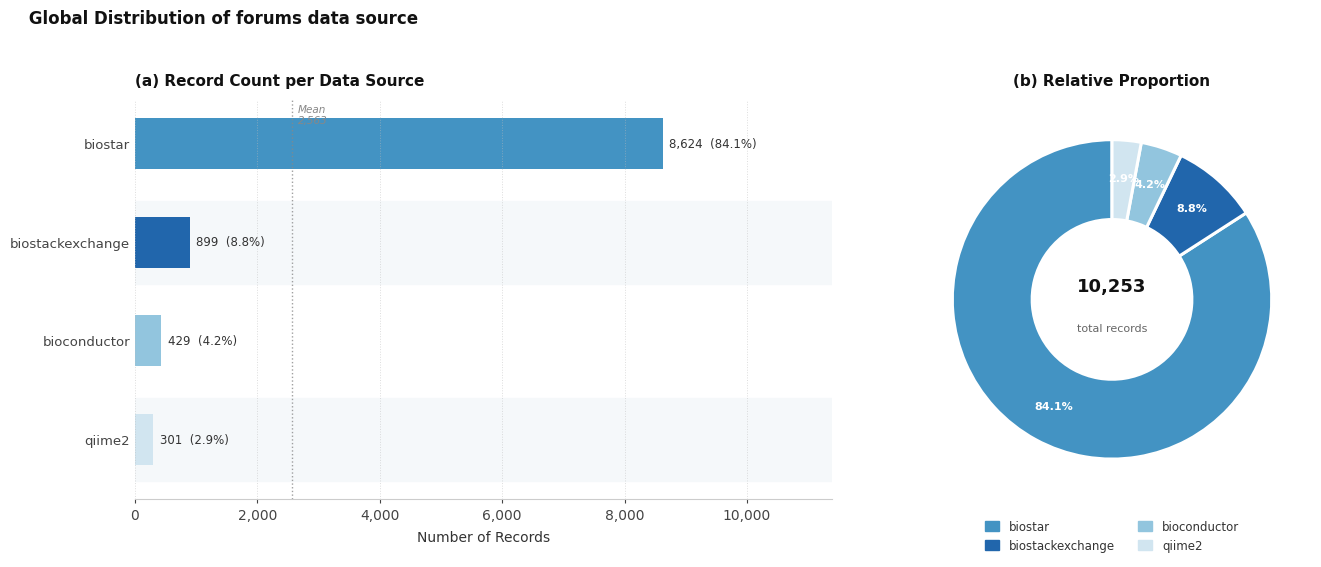

source
biostar             8624
biostackexchange     899
bioconductor         429
qiime2               301


In [ ]:

import matplotlib.ticker as mticker
import matplotlib.patches as mpatches

counts  = df['source'].value_counts()
sources = counts.index.tolist()
total   = counts.sum()


NATURE_PALETTE = [
    '#4393C3', '#2166AC', '#92C5DE', '#D1E5F0',
    '#F4A582', '#CA0020', '#74ADD1', '#ABD9E9'
]
colors = [NATURE_PALETTE[i % len(NATURE_PALETTE)] for i in range(len(sources))]
src_colors = dict(zip(sources, colors))

plt.rcParams.update({
    'font.family'       : 'DejaVu Sans',
    'font.size'         : 10,
    'axes.linewidth'    : 0.8,
    'axes.spines.top'   : False,
    'axes.spines.right' : False,
    'axes.spines.left'  : False,
    'xtick.major.size'  : 3,
    'ytick.major.size'  : 0,
    'xtick.color'       : '#444444',
    'ytick.color'       : '#444444',
    'savefig.dpi'       : 300,
    'savefig.bbox'      : 'tight',
    'savefig.facecolor' : 'white',
})

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5),
                         gridspec_kw={'width_ratios': [1.3, 1]})
fig.patch.set_facecolor('white')

ax = axes[0]
ax.set_facecolor('white')

bar_sources = sources[::-1]
bar_vals    = [counts[s] for s in bar_sources]
bar_colors  = [src_colors[s] for s in bar_sources]

bars = ax.barh(bar_sources, bar_vals, color=bar_colors,
               height=0.52, edgecolor='none')


for i, src in enumerate(bar_sources):
    if i % 2 == 0:
        ax.axhspan(i - 0.42, i + 0.42, color='#F5F8FA', zorder=0)

for bar, src in zip(bars, bar_sources):
    val = counts[src]
    pct = val / total * 100
    ax.text(bar.get_width() + counts.max() * 0.012,
            bar.get_y() + bar.get_height() / 2,
            f'{val:,}  ({pct:.1f}%)',
            va='center', ha='left', fontsize=8.5, color='#333333')

# Mean reference line
mean_val = counts.mean()
ax.axvline(mean_val, color='#888888', linewidth=1.0,
           linestyle=':', alpha=0.8, zorder=3)
ax.text(mean_val + counts.max() * 0.012, len(sources) - 0.6,
        f'Mean\n{mean_val:,.0f}',
        color='#888888', fontsize=7.5, style='italic', va='top')

ax.set_xlim(0, counts.max() * 1.32)
ax.set_xlabel('Number of Records', labelpad=6, fontsize=10, color='#333333')
ax.set_title('(a) Record Count per Data Source', fontsize=11,
             fontweight='bold', pad=10, color='#111111', loc='left')
ax.tick_params(axis='y', labelsize=9.5)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.grid(axis='x', linestyle=':', linewidth=0.7, alpha=0.5, color='#BBBBBB')
ax.spines['bottom'].set_color('#CCCCCC')
ax.spines['left'].set_visible(False)


ax2 = axes[1]
ax2.set_facecolor('white')

wedges, _, autotexts = ax2.pie(
    [counts[s] for s in sources],
    labels=None,
    colors=colors,
    autopct='%1.1f%%',
    pctdistance=0.76,
    startangle=90,
    wedgeprops=dict(width=0.50, edgecolor='white', linewidth=2.2),
    textprops={'fontsize': 8.5}
)
for at in autotexts:
    at.set_color('white')
    at.set_fontweight('bold')
    at.set_fontsize(8)

ax2.text(0, 0.08, f'{total:,}', ha='center', va='center',
         fontsize=13, fontweight='bold', color='#111111')
ax2.text(0, -0.18, 'total records', ha='center', va='center',
         fontsize=8, color='#666666')

legend_patches = [
    mpatches.Patch(color=src_colors[s], label=s) for s in sources
]
ax2.legend(handles=legend_patches,
           loc='lower center', bbox_to_anchor=(0.5, -0.16),
           ncol=2, frameon=False, fontsize=8.5, labelcolor='#333333',
           handlelength=1.2, handleheight=0.9, borderpad=0.4)

ax2.set_title('(b) Relative Proportion', fontsize=11,
              fontweight='bold', pad=10, color='#111111')

fig.suptitle(' Global Distribution of forums data source ',
             fontsize=12, fontweight='bold', color='#111111',
             y=1.03, x=0.02, ha='left')

plt.tight_layout()
plt.savefig('C:/Users/PC/Downloads/genomeer/images_VF/forums_sources1.png', dpi=600)
plt.show()
print(counts.to_string())

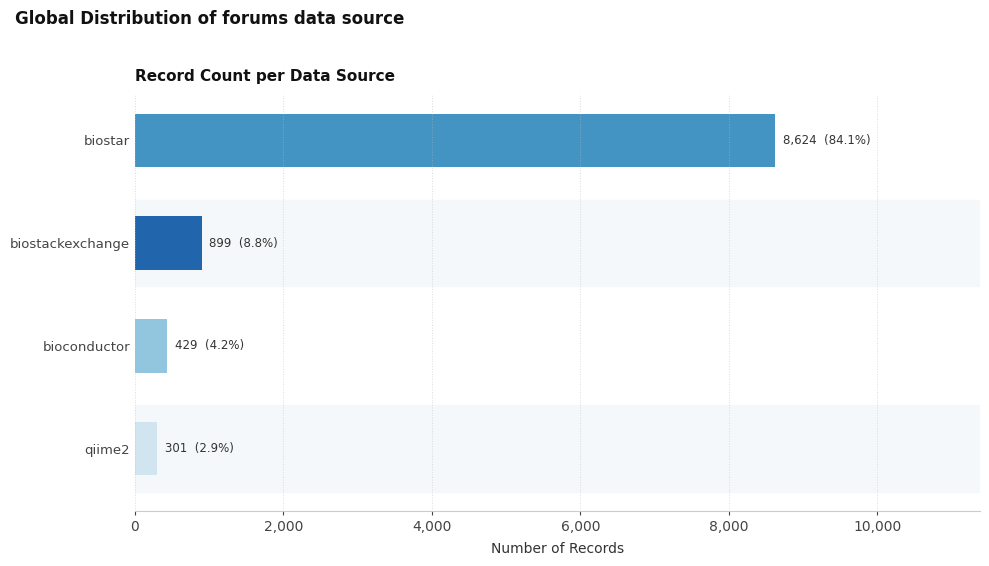

source
biostar             8624
biostackexchange     899
bioconductor         429
qiime2               301


In [6]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

counts  = df['source'].value_counts()
sources = counts.index.tolist()
total   = counts.sum()

NATURE_PALETTE = [
    '#4393C3', '#2166AC', '#92C5DE', '#D1E5F0',
    '#F4A582', '#CA0020', '#74ADD1', '#ABD9E9'
]
colors = [NATURE_PALETTE[i % len(NATURE_PALETTE)] for i in range(len(sources))]
src_colors = dict(zip(sources, colors))

plt.rcParams.update({
    'font.family'       : 'DejaVu Sans',
    'font.size'         : 10,
    'axes.linewidth'    : 0.8,
    'axes.spines.top'   : False,
    'axes.spines.right' : False,
    'axes.spines.left'  : False,
    'xtick.major.size'  : 3,
    'ytick.major.size'  : 0,
    'xtick.color'       : '#444444',
    'ytick.color'       : '#444444',
    'savefig.dpi'       : 600,
    'savefig.bbox'      : 'tight',
    'savefig.facecolor' : 'white',
})

fig, ax = plt.subplots(figsize=(10, 5.5))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

bar_sources = sources[::-1]
bar_vals    = [counts[s] for s in bar_sources]
bar_colors  = [src_colors[s] for s in bar_sources]

bars = ax.barh(bar_sources, bar_vals, color=bar_colors,
               height=0.52, edgecolor='none')

for i, src in enumerate(bar_sources):
    if i % 2 == 0:
        ax.axhspan(i - 0.42, i + 0.42, color='#F5F8FA', zorder=0)

for bar, src in zip(bars, bar_sources):
    val = counts[src]
    pct = val / total * 100
    ax.text(bar.get_width() + counts.max() * 0.012,
            bar.get_y() + bar.get_height() / 2,
            f'{val:,}  ({pct:.1f}%)',
            va='center', ha='left', fontsize=8.5, color='#333333')

ax.set_xlim(0, counts.max() * 1.32)
ax.set_xlabel('Number of Records', labelpad=6, fontsize=10, color='#333333')
ax.set_title('Record Count per Data Source', fontsize=11,
             fontweight='bold', pad=10, color='#111111', loc='left')

ax.tick_params(axis='y', labelsize=9.5)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.grid(axis='x', linestyle=':', linewidth=0.7, alpha=0.5, color='#BBBBBB')
ax.spines['bottom'].set_color('#CCCCCC')
ax.spines['left'].set_visible(False)

fig.suptitle('Global Distribution of forums data source',
             fontsize=12, fontweight='bold', color='#111111',
             y=1.02, x=0.02, ha='left')

plt.tight_layout()
plt.savefig('C:/Users/PC/Downloads/genomeer/images_VF/forums_sources.png', dpi=600)
plt.show()

print(counts.to_string())

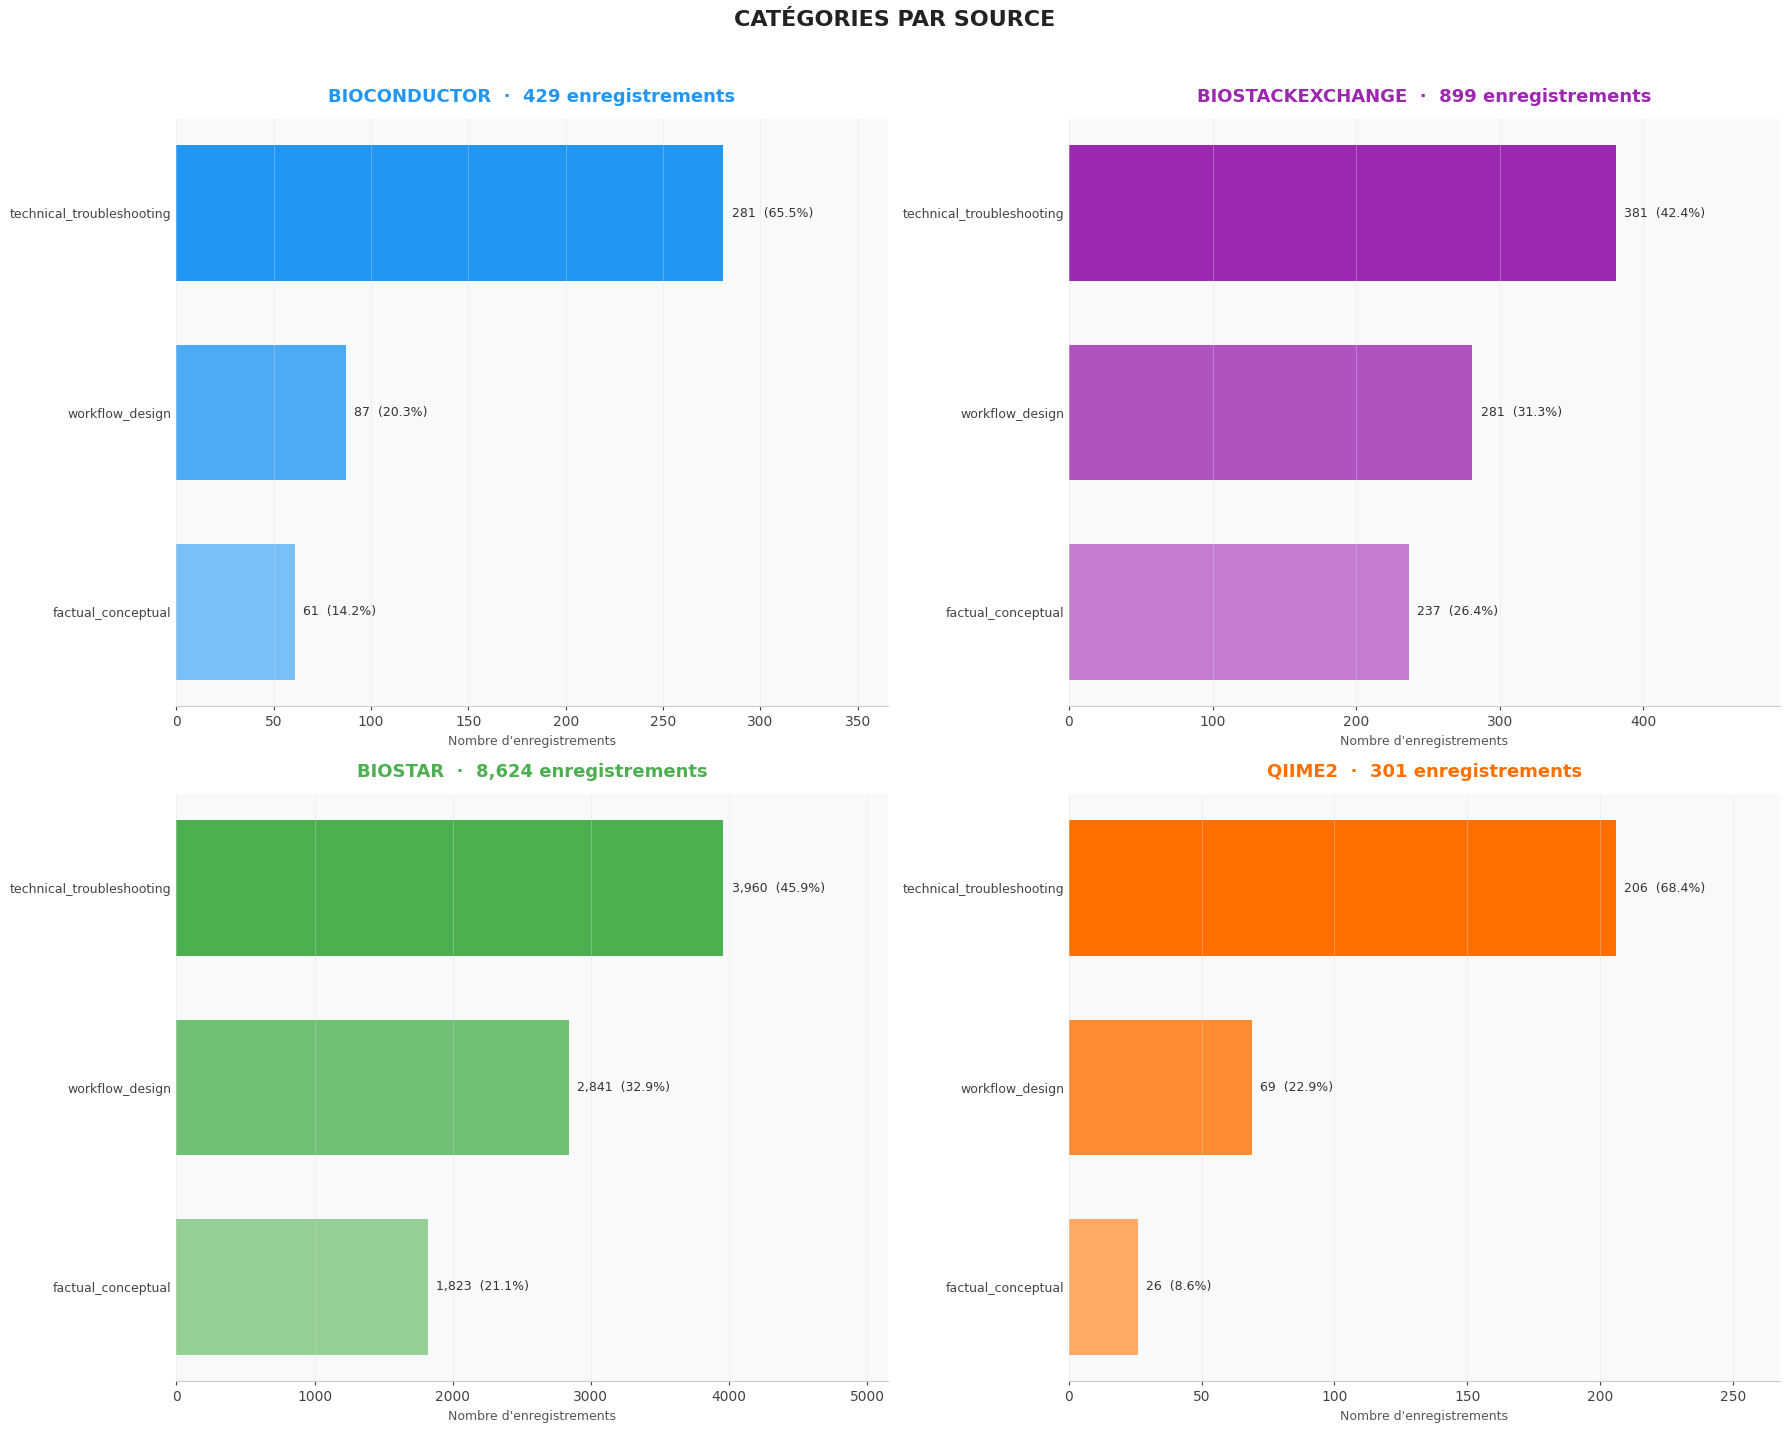

 fig2_categories_par_source_separees.png


In [8]:
sources_available = [s for s in SOURCE_COLORS if s in df['source'].unique()]
n = len(sources_available)
ncols = 2
nrows = (n + 1) // 2

fig, axes = plt.subplots(nrows, ncols, figsize=(18, 7 * nrows))
fig.patch.set_facecolor('white')
fig.suptitle('CATÉGORIES PAR SOURCE', fontsize=16, fontweight='bold', color='#222222', y=1.02)

axes_flat = axes.flatten() if n > 1 else [axes]

for idx, src in enumerate(sources_available):
    ax = axes_flat[idx]
    ax.set_facecolor('#F8F9FA')

    
    src_cats = df[df['source'] == src]['category'].value_counts().head(15)
    total_src = len(df[df['source'] == src])
    
    if src_cats.empty:
        ax.set_title(f'{src.upper()}  ·  0 catégories', color=SOURCE_COLORS.get(src, '#333'), fontsize=12, fontweight='bold')
        ax.text(0.5, 0.5, "Aucune catégorie", ha='center', va='center', transform=ax.transAxes, color='#888')
        continue

    color_main = SOURCE_COLORS[src]

    
    intensities = [0.4 + 0.6 * (1 - i / len(src_cats)) for i in range(len(src_cats))]
    import matplotlib.colors as mc
    rgb = mc.to_rgb(color_main)
    bar_colors = [(min(rgb[0]*k + (1-k), 1), min(rgb[1]*k + (1-k), 1), min(rgb[2]*k + (1-k), 1))
                  for k in intensities[::-1]]

   
    bars = ax.barh(src_cats.index[::-1], src_cats.values[::-1],
                   color=bar_colors, height=0.68, edgecolor='none')

  
    for bar, val in zip(bars, src_cats.values[::-1]):
        pct = (val / total_src) * 100
        ax.text(bar.get_width() + src_cats.max() * 0.015,
                bar.get_y() + bar.get_height() / 2,
                f'{val:,}  ({pct:.1f}%)', va='center', color='#333333', fontsize=9)

    
    ax.set_title(f'{src.upper()}  ·  {total_src:,} enregistrements',
                 color=color_main, fontsize=13, fontweight='bold', pad=12)
    ax.set_xlim(0, src_cats.max() * 1.30)  
    ax.grid(axis='x', alpha=0.4)
    ax.set_xlabel('Nombre d\'enregistrements', color='#555555', fontsize=9)
    
    
    ax.tick_params(axis='y', labelsize=9)


for idx in range(n, len(axes_flat)):
    axes_flat[idx].set_visible(False)

plt.tight_layout()

plt.show()
print(' fig2_categories_par_source_separees.png')

In [9]:

tag_rows = []
for _, row in df.iterrows():
    for tag in row['tags_list']:
        tag_rows.append({'source': row['source'], 'tag': tag, 'category': row['category']})

df_tags = pd.DataFrame(tag_rows)

print(f'Total occurrences de tags  : {len(df_tags):,}')
print(f'Tags uniques               : {df_tags["tag"].nunique():,}')

print(df_tags['tag'].value_counts().head(30).to_string())

Total occurrences de tags  : 33,358
Tags uniques               : 3,498
tag
Amplicon-specific (16S/18S/ITS)    4775
RNA-Seq                            1021
Assembly                            780
genome                              604
alignment                           535
R                                   515
sequencing                          474
assembly                            437
next-gen                            401
gene                                322
blast                               308
samtools                            302
sequence                            281
bam                                 260
annotation                          257
fastq                               255
fasta                               210
SNP                                 206
taxonomy                            192
bwa                                 183
vcf                                 176
rna-seq                             175
metagenomics                        168
ncbi 

In [10]:
import pandas as pd
import re


tag_rows = []
for _, row in df.iterrows():
    for tag in row['tags_list']:
        tag_rows.append({
            'source': row['source'],
            'tag': tag,
            'category': row['category']
        })

df_tags = pd.DataFrame(tag_rows)

print(f'Total occurrences de tags  : {len(df_tags):,}')
print(f'Tags uniques               : {df_tags['tag'].nunique():,}')


df_tags['tag_clean'] = (
    df_tags['tag']
    .str.lower()
    .str.strip()
    .str.replace('-', ' ', regex=False)
    .str.replace('_', ' ', regex=False)
)


pattern = r'quality\s*co+ntrol'

quality_matches = df_tags[
    df_tags['tag_clean'].str.contains(pattern, regex=True, na=False)
]

print("\nquality_control (et variantes) :")
print(quality_matches['tag'].value_counts().to_string())

print(f"\nTotal détecté : {len(quality_matches)}")

Total occurrences de tags  : 33,358
Tags uniques               : 3,498

quality_control (et variantes) :
tag
quality-control    15
qualitycontrol      6
quality control     5
Quality-control     2
Quality-Control     2

Total détecté : 30


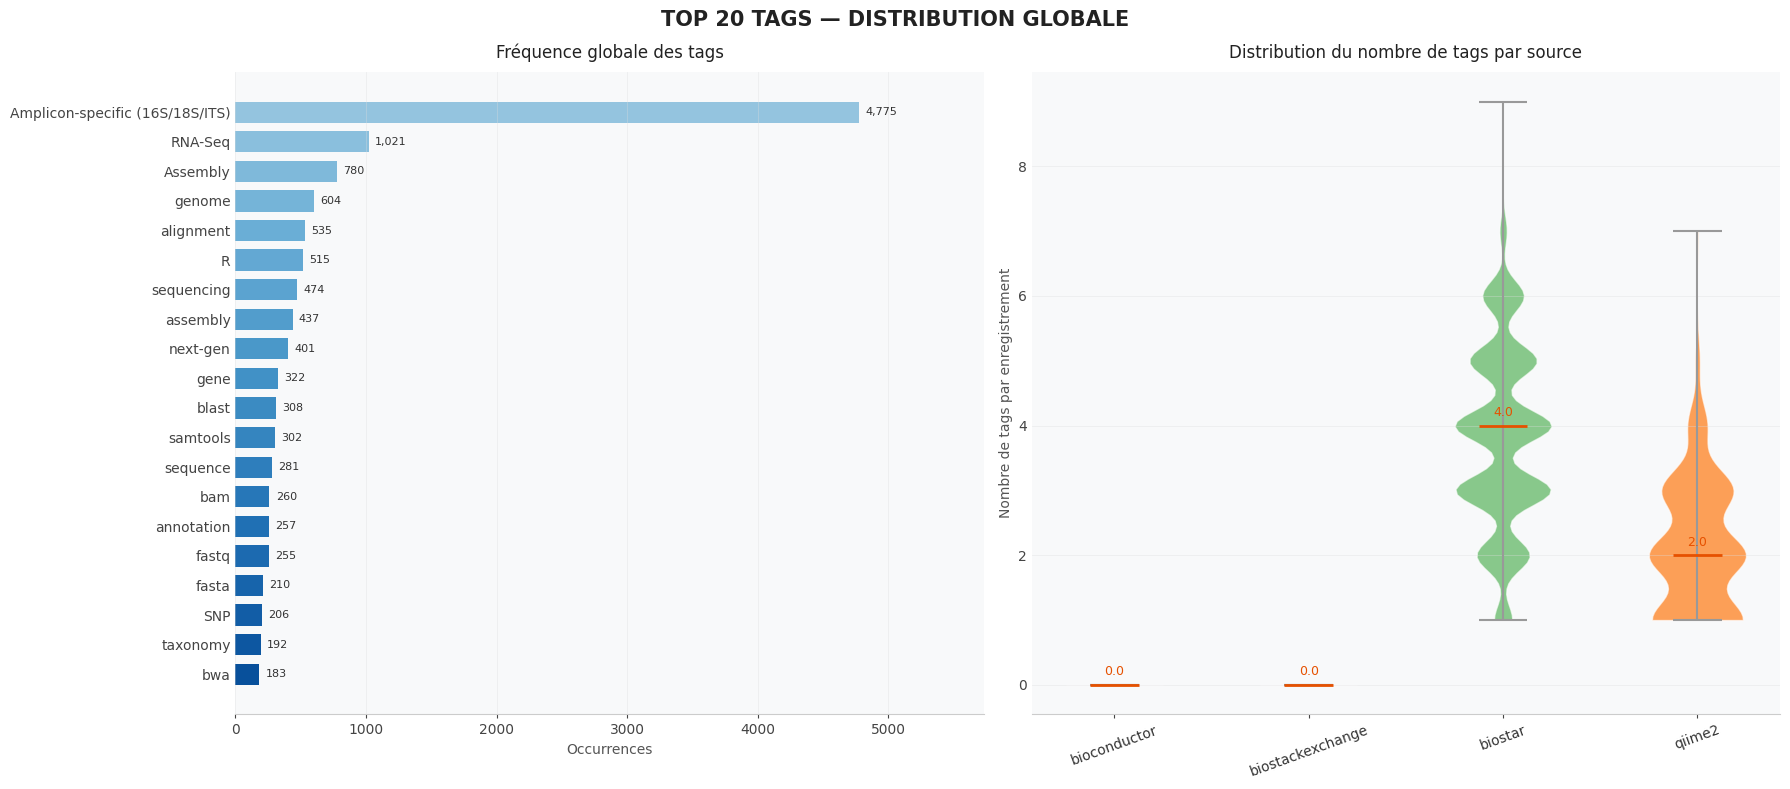

In [11]:
top_n   = 20
top_tags = df_tags['tag'].value_counts().head(top_n)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fig.patch.set_facecolor('white')
fig.suptitle(f'TOP {top_n} TAGS — DISTRIBUTION GLOBALE', fontsize=15,
             fontweight='bold', color='#222222')


ax = axes[0]
ax.set_facecolor('#F8F9FA')
cmap = plt.cm.Blues
bar_colors = [cmap(0.4 + 0.5 * i / top_n) for i in range(top_n)]

bars = ax.barh(top_tags.index[::-1], top_tags.values[::-1],
               color=bar_colors[::-1], edgecolor='none', height=0.72)
for bar, val in zip(bars, top_tags.values[::-1]):
    ax.text(bar.get_width() + top_tags.max() * 0.01,
            bar.get_y() + bar.get_height() / 2,
            f'{val:,}', va='center', color='#333333', fontsize=8)

ax.set_xlim(0, top_tags.max() * 1.2)
ax.set_xlabel('Occurrences', color='#555555')
ax.set_title('Fréquence globale des tags', color='#222222', pad=10)
ax.grid(axis='x', alpha=0.4)


ax2 = axes[1]
ax2.set_facecolor('#F8F9FA')
sources_order = list(SOURCE_COLORS.keys())
data_violin   = [df[df['source'] == s]['n_tags'].values for s in sources_order
                 if s in df['source'].unique()]
actual_sources = [s for s in sources_order if s in df['source'].unique()]

parts = ax2.violinplot(data_violin, positions=range(len(actual_sources)),
                       showmedians=True, showextrema=True)
for i, (pc, src) in enumerate(zip(parts['bodies'], actual_sources)):
    pc.set_facecolor(SOURCE_COLORS[src])
    pc.set_alpha(0.65)
    pc.set_edgecolor('white')

parts['cmedians'].set_color('#E65100')
parts['cmedians'].set_linewidth(2)
parts['cmins'].set_color('#999999')
parts['cmaxes'].set_color('#999999')
parts['cbars'].set_color('#999999')

for i, src in enumerate(actual_sources):
    med = df[df['source'] == src]['n_tags'].median()
    ax2.text(i, med + 0.15, f'{med:.1f}', ha='center', color='#E65100', fontsize=9)

ax2.set_xticks(range(len(actual_sources)))
ax2.set_xticklabels(actual_sources, color='#333333', rotation=20)
ax2.set_ylabel('Nombre de tags par enregistrement', color='#555555')
ax2.set_title('Distribution du nombre de tags par source', color='#222222', pad=10)
ax2.grid(axis='y', alpha=0.4)

plt.tight_layout()

plt.show()


creation tags for two other sources 

In [12]:
import re

BIO_DICTIONARY = {
    "RNA-Seq": [r"rna-seq", r"rnaseq", r"transcriptom"],
    "Single-cell": [r"single-cell", r"scrna", r"scatac", r"seurat"],
    "Genomics (WGS/WES)": [r"wgs", r"wes", r"whole genome", r"genom"],
    "Metagenomics": [r"metagenomi", r"microbiome"],
    "Amplicon (16S/18S/ITS)": [r"16s", r"18s", r"its", r"amplicon"],
    "Epigenomics": [r"epigenomi", r"methylation", r"bisulfite"],
    "Proteomics": [r"proteomi", r"mass spec"],
    "Alignment": [r"alignment", r"aligner", r"mapping"],
    "Assembly": [r"assembly", r"assembler", r"de novo"],
    "Variant Calling": [r"variant calling", r"vcf", r"snp", r"snv", r"polymorphism"],
    "Differential Expression": [r"differential expression", r"deg", r"deseq2", r"edger"],
    "Gene Annotation": [r"annotation", r"gene ontology", r"kegg"],
    "Phylogeny": [r"phylogeny", r"phylogenetic", r"tree", r"cladogram"],
    "ChIP-Seq": [r"chip-seq", r"chipseq", r"peak calling"],
    "ATAC-Seq": [r"atac-seq", r"atacseq"],
    "Quality Control": [r"quality control", r"qc", r"fastqc", r"trimming", r"cutadapt"],
    "Clustering/PCA": [r"clustering", r"pca", r"tsne", r"umap", r"dimensionality"],
    "Pathway Analysis": [r"pathway", r"gsea", r"enrichment"],
    "Microarray": [r"microarray", r"affymetrix", r"illumina array"],
    "CRISPR": [r"crispr", r"cas9"],
    "Long-read (Nanopore/PacBio)": [r"nanopore", r"pacbio", r"long-read", r"ont"],
    "Short-read (Illumina)": [r"illumina", r"short-read"],
    "R / RStudio": [r"\bR\b", r"rstudio", r"ggplot2"],
    "Python / BioPython": [r"python", r"biopython", r"pandas"],
    "Bioconductor": [r"bioconductor", r"granges", r"biostrings"],
    "QIIME2": [r"qiime", r"qiime2"],
    "DADA2": [r"dada2"],
    "GATK": [r"gatk"],
    "BLAST": [r"blast", r"blastn", r"blastp"],
    "BWA / Bowtie": [r"bwa", r"bowtie"],
    "SAM/BAM Tools": [r"samtools", r"bam", r"sam file"],
    "BEDTools": [r"bedtools", r"bed file"],
    "FASTA / FASTQ": [r"fasta", r"fastq"],
    "Sequence Motif": [r"motif", r"meme suite"],
    "Structural Biology": [r"pdb", r"protein structure", r"pymol"],
    "Machine Learning": [r"machine learning", r"deep learning", r"random forest", r"neural network"],
    "Network Analysis": [r"network", r"cytoscape", r"wgcna"],
    "Visualization": [r"visualization", r"plot", r"heatmap"]
}



tags_added = 0
sources_to_fix = ['bioconductor', 'biostackexchange']


for idx, row in df.iterrows():
    if row['source'] in sources_to_fix:
       
        full_text = str(row['instruction']) + " " + str(row['input']) + " " + str(row['output'])

        found_tags = set(row['tags_list']) 
        

        for tag_name, patterns in BIO_DICTIONARY.items():
            for pat in patterns:

                regex_flag = 0 if pat == r"\bR\b" else re.IGNORECASE
                if re.search(r"\b" + pat + r"\b", full_text, flags=regex_flag):
                    found_tags.add(tag_name)
                    tags_added += 1
                    break
        
        
        df.at[idx, 'tags_list'] = list(found_tags)
        df.at[idx, 'n_tags'] = len(found_tags)

tag_rows = []
for _, row in df.iterrows():
    for tag in row['tags_list']:
        tag_rows.append({'source': row['source'], 'tag': tag, 'category': row['category']})

df_tags = pd.DataFrame(tag_rows)

 Tags par Source 
 

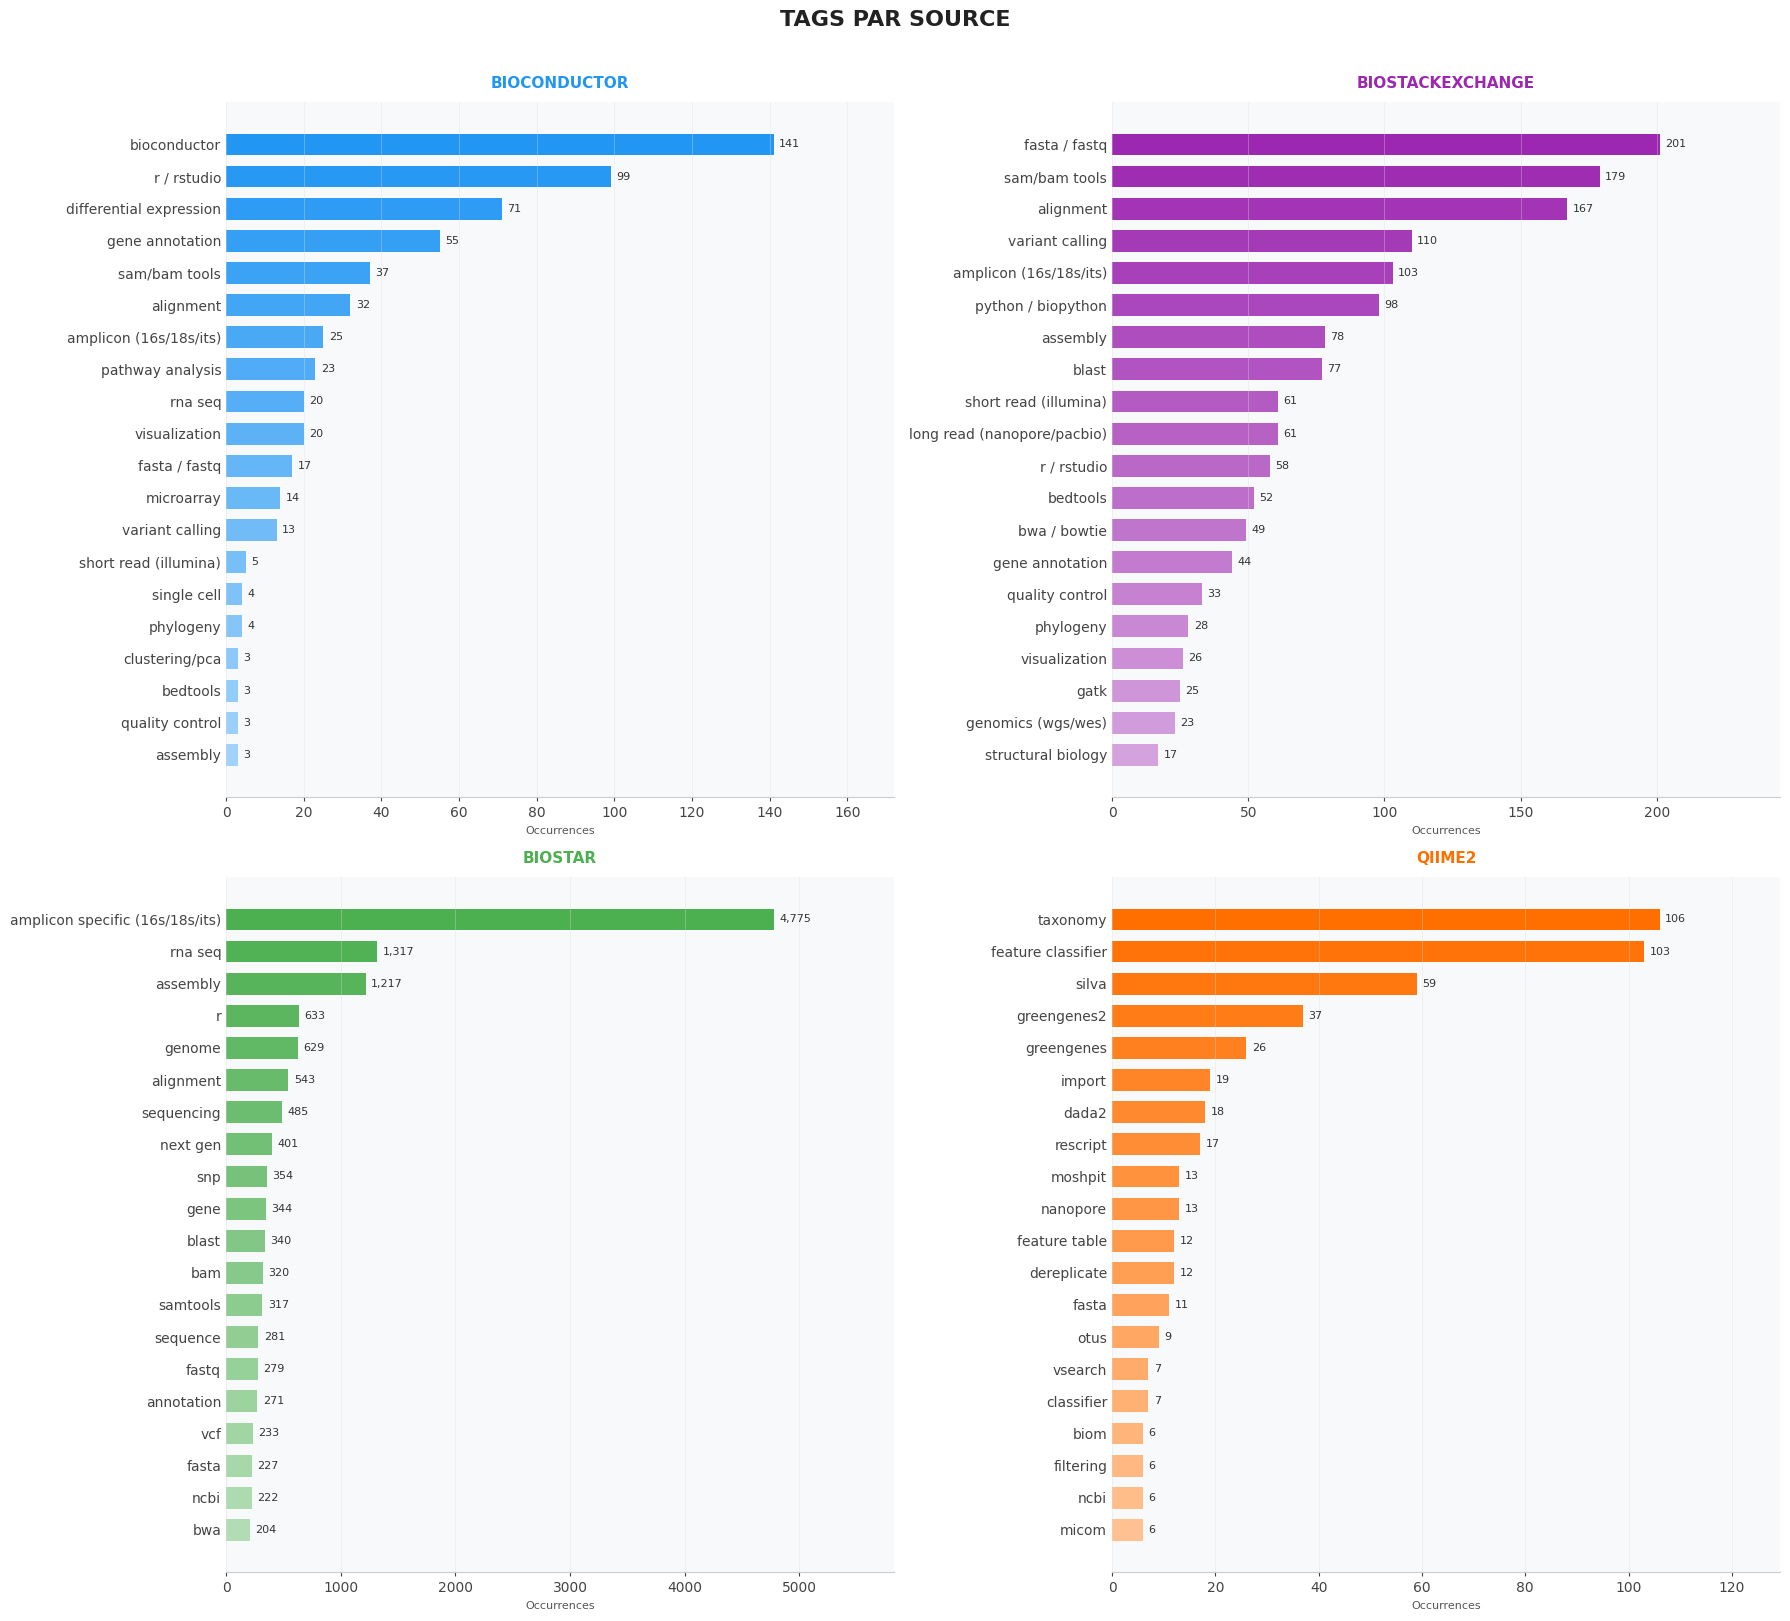

In [13]:
import matplotlib.pyplot as plt
import matplotlib.colors as mc


df_tags['tag_clean'] = (
    df_tags['tag']
    .str.strip()
    .str.lower()
    .str.replace('-', ' ', regex=False)
)

sources_available = [s for s in SOURCE_COLORS if s in df['source'].unique()]
n = len(sources_available)
ncols = 2
nrows = (n + 1) // 2

fig, axes = plt.subplots(nrows, ncols, figsize=(18, 8 * nrows))
fig.patch.set_facecolor('white')
fig.suptitle('TAGS PAR SOURCE', fontsize=16, fontweight='bold', color='#222222', y=1.01)

axes_flat = axes.flatten() if n > 1 else [axes]

for idx, src in enumerate(sources_available):
    ax = axes_flat[idx]
    ax.set_facecolor('#F8F9FA')

    src_tags = (
        df_tags[df_tags['source'] == src]['tag_clean']
        .value_counts()
        .head(20)
    )

    color_main = SOURCE_COLORS[src]
    total_tags_src = len(df_tags[df_tags['source'] == src])

    if src_tags.empty:
        ax.set_title(f'{src.upper()} · 0 occurrences',
                     color=color_main, fontsize=11, fontweight='bold', pad=10)
        ax.text(0.5, 0.5, "Aucun tag disponible",
                ha='center', va='center', transform=ax.transAxes, color='#888888')
        ax.set_xlim(0, 1)
        continue

    
    intensities = [0.4 + 0.6 * (1 - i / len(src_tags)) for i in range(len(src_tags))]
    rgb = mc.to_rgb(color_main)
    bar_colors = [
        (min(rgb[0]*k + (1-k), 1),
         min(rgb[1]*k + (1-k), 1),
         min(rgb[2]*k + (1-k), 1))
        for k in intensities[::-1]
    ]

    bars = ax.barh(
        src_tags.index[::-1],
        src_tags.values[::-1],
        color=bar_colors,
        height=0.68,
        edgecolor='none'
    )

    for bar, val in zip(bars, src_tags.values[::-1]):
        ax.text(
            bar.get_width() + src_tags.max() * 0.01,
            bar.get_y() + bar.get_height() / 2,
            f'{val:,}',
            va='center',
            color='#333333',
            fontsize=8
        )

    ax.set_title(
        f'{src.upper()}',
        color=color_main,
        fontsize=11,
        fontweight='bold',
        pad=10
    )
    ax.set_xlim(0, src_tags.max() * 1.22)
    ax.grid(axis='x', alpha=0.4)
    ax.set_xlabel('Occurrences', color='#555555', fontsize=8)
for idx in range(n, len(axes_flat)):
    axes_flat[idx].set_visible(False)

plt.tight_layout()
plt.savefig('fig4_tags_par_source.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

distribution de tag par category

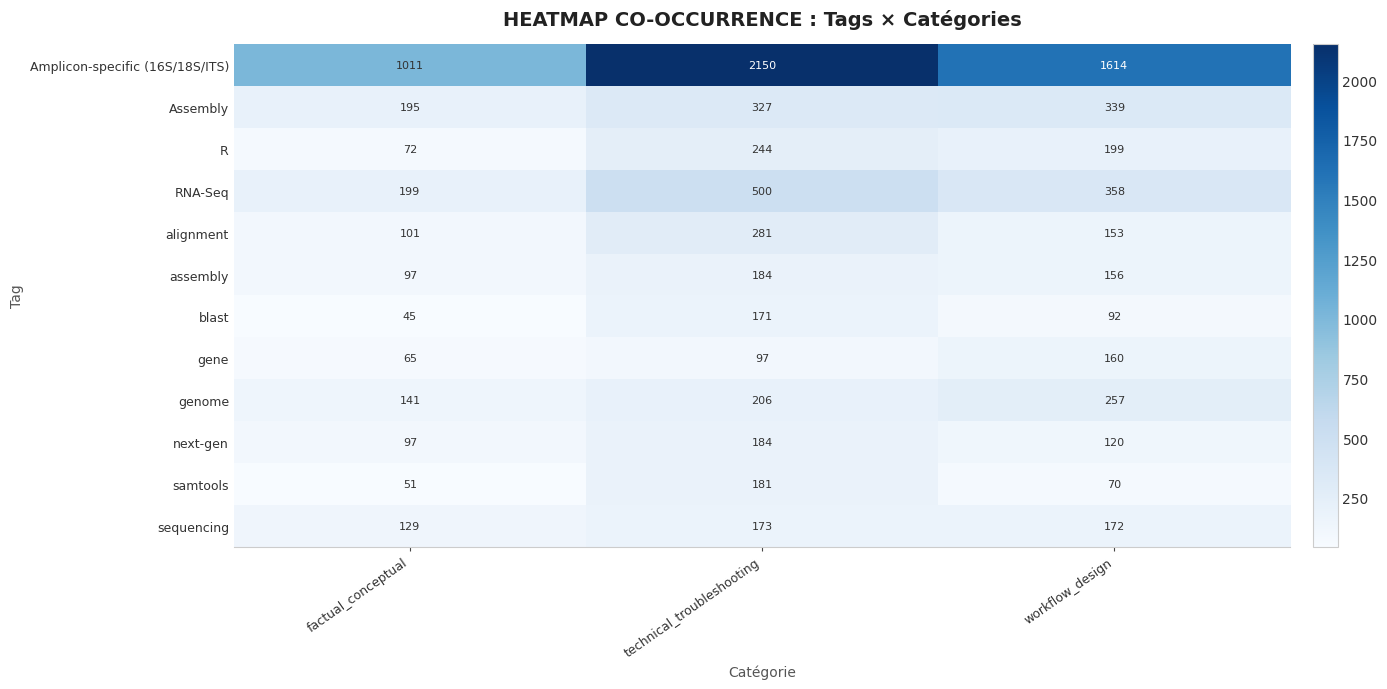

In [14]:

top12_tags = df_tags['tag'].value_counts().head(12).index.tolist()
top8_cats  = df['category'].value_counts().head(8).index.tolist()

df_co = df_tags[df_tags['tag'].isin(top12_tags) & df_tags['category'].isin(top8_cats)]
co_matrix = df_co.pivot_table(index='tag', columns='category', aggfunc='size', fill_value=0)

fig, ax = plt.subplots(figsize=(14, 7))
fig.patch.set_facecolor('white')
ax.set_facecolor('#F8F9FA')

im = ax.imshow(co_matrix.values, cmap='Blues', aspect='auto')

ax.set_xticks(range(len(co_matrix.columns)))
ax.set_xticklabels(co_matrix.columns, rotation=35, ha='right', color='#333333', fontsize=9)
ax.set_yticks(range(len(co_matrix.index)))
ax.set_yticklabels(co_matrix.index, color='#333333', fontsize=9)

for i in range(len(co_matrix.index)):
    for j in range(len(co_matrix.columns)):
        val = co_matrix.values[i, j]
        if val > 0:
            ax.text(j, i, f'{val}', ha='center', va='center',
                    fontsize=8, color='white' if val > co_matrix.values.max()*0.5 else '#333333')

cbar = plt.colorbar(im, ax=ax, fraction=0.025, pad=0.02)
cbar.ax.yaxis.set_tick_params(color='#333333')
plt.setp(cbar.ax.yaxis.get_ticklabels(), color='#333333')

ax.set_title('HEATMAP CO-OCCURRENCE : Tags × Catégories',
             color='#222222', fontsize=14, fontweight='bold', pad=14)
ax.set_xlabel('Catégorie', color='#555555')
ax.set_ylabel('Tag', color='#555555')

plt.tight_layout()
plt.savefig('fig5_tags_vs_categories.png', dpi=150, bbox_inches='tight',
            facecolor='white')
plt.show()


In [15]:
import re
def normalize_tag(tag):
    if pd.isna(tag):
        return tag

    tag = tag.lower().strip()
    
   
    tag = tag.replace('-', ' ')
    tag = tag.replace('_', ' ')
    
    
    tag = re.sub(r'\s+', ' ', tag)

    
    corrections = {
        'rna seq': 'rna_seq',
        'rrna':'rna',
        'rna sequencing': 'rna_seq',
        'rnaseq': 'rna_seq',               
        'transcriptome analysis': 'transcriptomics',
        'transcriptome': 'transcriptomics', 
        'fasta':'fasta / fastq',
        'fastq':'fasta / fastq',
        'blastn': 'blast',
        'blastp': 'blast',
        'blastx': 'blast',
        'quality filtering': 'quality control',
        'quality check': 'quality control',
        'quality': 'quality control',     
        'filter': 'filtering',            
        'amplicon specific (16s/18s/its)': 'amplicon',
        'amplicon (16s/18s/its)': 'amplicon',
        'long read (nanopore/pacbio)': 'long read',
        'pacbio': 'long read',              
        'nanopore': 'long read',           
        'short read (illumina)': 'short read',
        'python / biopython': 'biopython',
        'gff3': 'gff',
        'gtf': 'gff',             
        'bowtie2': 'bowtie',     
        'hisat2': 'hisat',        
        'trimmomatic': 'trimming',
        'cutadapt': 'trimming',
        'denovo': 'de novo assembly', 
        'contigs': 'assembly',
        'spades': 'assembly',     
        'abyss': 'assembly',      
        'velvet': 'assembly',     
        'variant': 'variant calling',
        'vcf': 'variant calling', 
        'uniprot': 'database',
        'silva': 'database',
        'go': 'gene ontology',
        'wgs': 'whole genome sequencing',
        'fpkm': 'rna_seq',       
        'featurecounts': 'rna_seq', 
        'bwa mem': 'bwa',
        'bwa / bowtie': 'alignment',  
        'bbmap': 'alignment',
        'calling': 'variant calling',
        'bcftools': 'variant calling', 
        'expression': 'differential expression',
        'edger': 'differential expression',     
        'seurat': 'single cell',                 
        'ensembl': 'database',
        'kegg': 'database',
        'pfam': 'database',
        'tcga': 'database',
        'ucsc': 'database',
        'sra': 'database',
        'biomart': 'database',
        'igv': 'visualization',
        'adapter': 'trimming', 
        'metagenome': 'metagenomics', 
        'orthologs': 'orthology',     
        'annoations':'annotation',
        'r':'r / rstudio',
        'rna':'rna_seq',
        'next gen': 'sequencing',
        'ngs': 'sequencing',
        'illumina': 'sequencing',
         'sam': 'sam/bam tools',
        'bam': 'sam/bam tools',
        'samtools': 'sam/bam tools',
        'picard': 'sam/bam tools',
        'fastqc': 'quality control', 
        'ncbi': 'database',
        'mapping': 'alignment',    
        'bwa': 'alignment',          
        'bowtie': 'alignment',       
        'bedtools': 'bed',
        'expression': 'differential expression',
        'deseq2': 'differential expression',
        'gene annotation': 'annotation',
    }

    if tag in corrections:
        tag = corrections[tag]

    return tag



df_tags['tag_clean'] = df_tags['tag'].apply(normalize_tag)





In [16]:

normalized_tags_map = (
    df_tags.groupby(df_tags.index // 1)  
   
)

df_tags_norm = df_tags.copy()
df_tags_norm['tag'] = df_tags_norm['tag_clean']  


tag_rows_norm = []
for i, row in df.iterrows():
    for tag in row['tags_list']:
        tag_rows_norm.append({
            'row_idx': i,
            'source':  row['source'],
            'tag':     tag,
            'category': row['category']
        })

df_tags_with_idx = pd.DataFrame(tag_rows_norm)
df_tags_with_idx['tag_clean'] = df_tags_with_idx['tag'].apply(normalize_tag)

# Grouper par row_idx → liste de tags normalisés dédoublonnés
normalized_map = (
    df_tags_with_idx.groupby('row_idx')['tag_clean']
    .apply(lambda tags: list(set(tags)))
    .to_dict()
)

# 2. Mettre à jour df avec les tags normalisés
df['tags_normalized'] = df.index.map(lambda i: normalized_map.get(i, []))

# 3. Réécrire le fichier combiné avec tags normalisés
output_path = Path('combined_dataset_normalized.jsonl')
total_written = 0

with open(output_path, 'w', encoding='utf-8') as out_f:
    for idx, row in df.iterrows():
        record = {
            "instruction": row['instruction'],
            "input":       row['input'],
            "output":      row['output'],
            "metadata": {
                "tags":     row['tags_normalized'],   # ← tags normalisés
                "category": row['category'],
                "model":    row['model'],
                "source":   row['source'],
            }
        }
        out_f.write(json.dumps(record, ensure_ascii=False) + '\n')
        total_written += 1

print(f"Fichier normalisé généré : {output_path}")
print(f"   → {total_written:,} enregistrements")

# 4. Vérification rapide
print("\n── Répartition par source ──")
for src in df['source'].unique():
    n = (df['source'] == src).sum()
    print(f"   {src:<25} → {n:,} enregistrements")

print("\n── Aperçu tags normalisés (5 premiers) ──")
for idx in list(df.index[:5]):
    print(f"   [{idx}] {df.loc[idx, 'source']:<20} → {df.loc[idx, 'tags_normalized']}")

Fichier normalisé généré : combined_dataset_normalized.jsonl
   → 10,253 enregistrements

── Répartition par source ──
   bioconductor              → 429 enregistrements
   biostackexchange          → 899 enregistrements
   biostar                   → 8,624 enregistrements
   qiime2                    → 301 enregistrements

── Aperçu tags normalisés (5 premiers) ──
   [0] bioconductor         → ['bioconductor']
   [1] bioconductor         → ['differential expression']
   [2] bioconductor         → ['differential expression']
   [3] bioconductor         → ['differential expression']
   [4] bioconductor         → ['amplicon', 'differential expression']


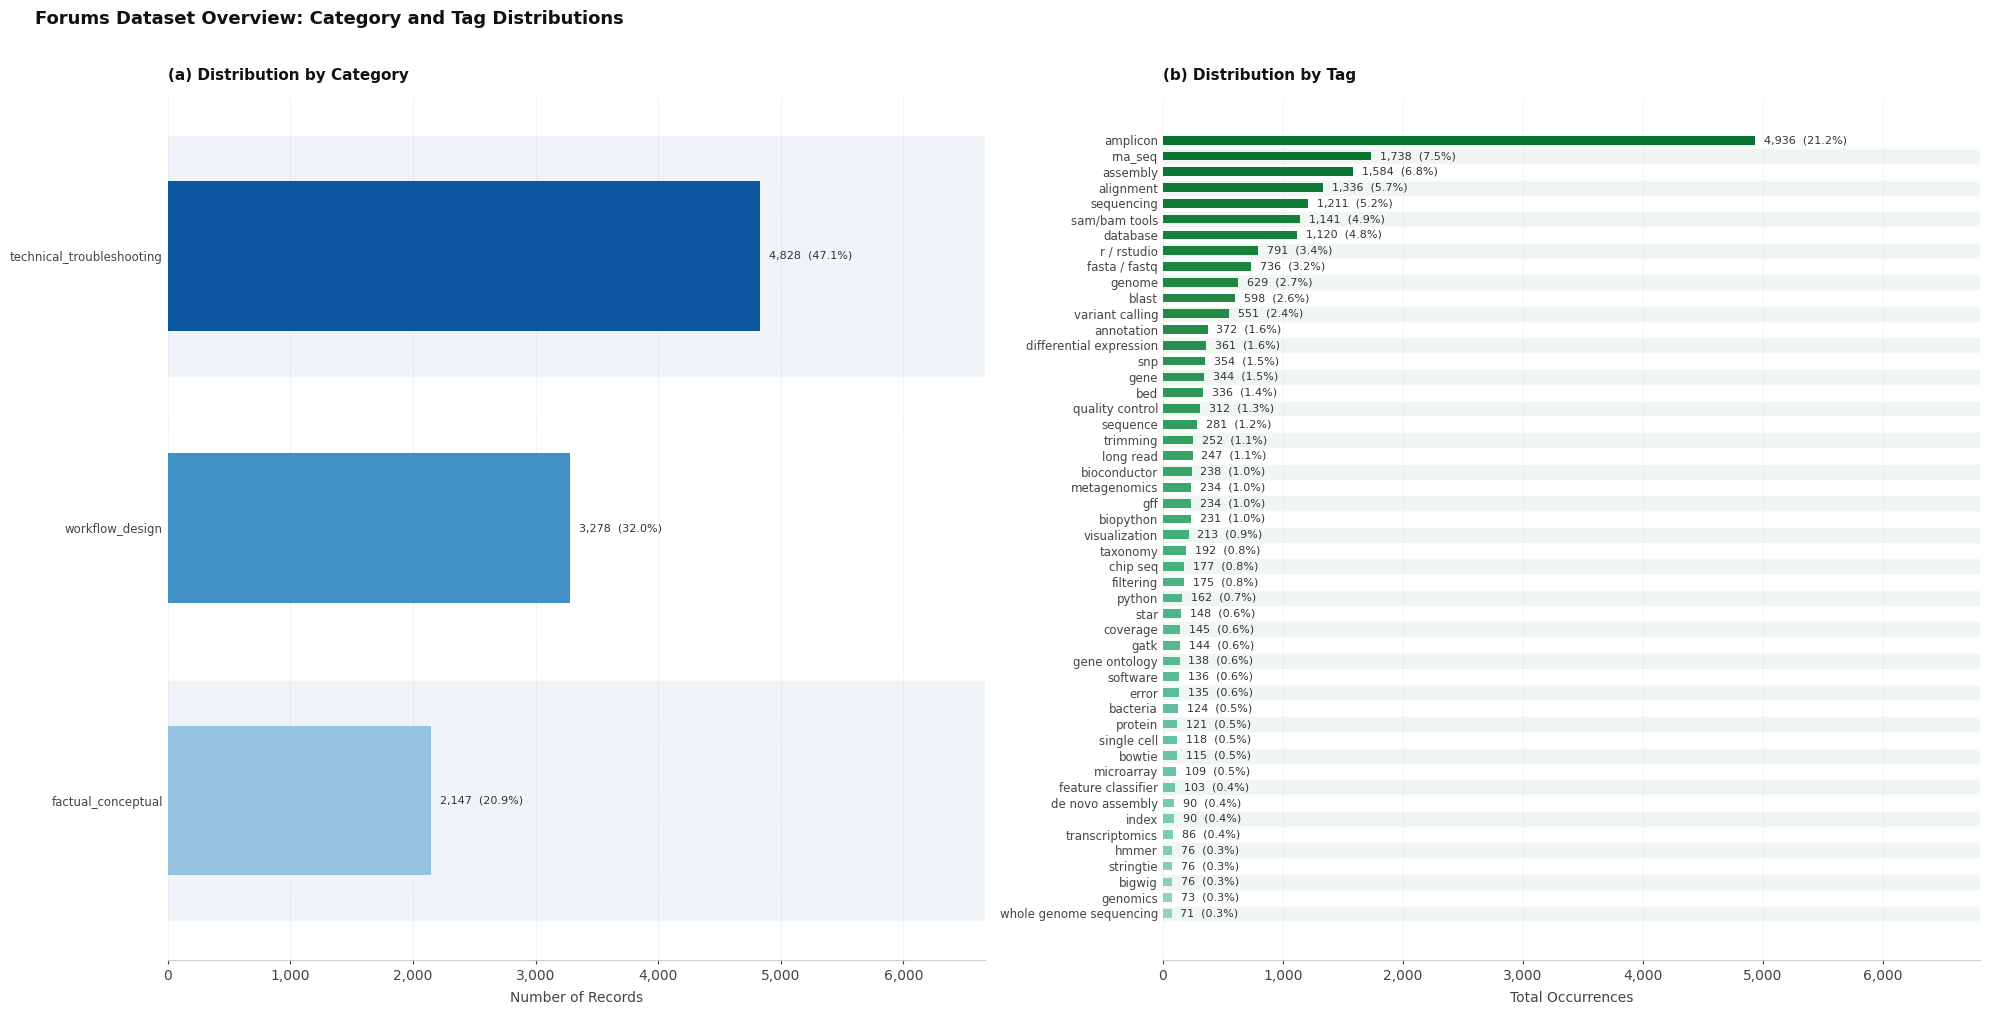

In [17]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

plt.rcParams.update({
    'font.family'      : 'DejaVu Sans',
    'font.size'        : 10,
    'axes.linewidth'   : 0.8,
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'axes.spines.left' : False,
    'savefig.dpi'      : 600,  
    'savefig.bbox'     : 'tight',
    'savefig.facecolor': 'white',
})

TOTAL_DATASET  = len(df)
top_cats_global = df['category'].value_counts().head(20)
top_tags_global = df_tags['tag_clean'].value_counts().head(50)

fig, axes = plt.subplots(1, 2, figsize=(20, 10))
fig.patch.set_facecolor('white')


ax1 = axes[0]
ax1.set_facecolor('white')

n_cats     = len(top_cats_global)
cmap_cat   = plt.cm.Blues
colors_cat = [cmap_cat(0.85 - 0.45 * i / max(n_cats-1, 1)) for i in range(n_cats)]

for i in range(n_cats):
    if i % 2 == 0:
        ax1.axhspan(i - 0.44, i + 0.44, color='#F0F4F8', zorder=0)

bars1 = ax1.barh(
    top_cats_global.index[::-1],
    top_cats_global.values[::-1],
    color=colors_cat[::-1],
    height=0.55, edgecolor='none', zorder=2
)
for bar, val in zip(bars1, top_cats_global.values[::-1]):
    pct_cat = val / top_cats_global.sum() * 100
    ax1.text(
        bar.get_width() + top_cats_global.max() * 0.015,
        bar.get_y() + bar.get_height() / 2,
        f'{val:,}  ({pct_cat:.1f}%)',
        va='center', ha='left', fontsize=8, color='#333333'
    )

ax1.set_title('(a) Distribution by Category',
              fontsize=11, fontweight='bold', pad=12, color='#111111', loc='left')
ax1.set_xlabel('Number of Records', labelpad=6, fontsize=10, color='#444444')
ax1.set_xlim(0, top_cats_global.max() * 1.38)
ax1.tick_params(axis='y', labelsize=8.5)
ax1.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax1.grid(axis='x', linestyle=':', linewidth=0.7, alpha=0.5, color='#BBBBBB', zorder=1)
ax1.spines['bottom'].set_color('#CCCCCC')


ax2 = axes[1]
ax2.set_facecolor('white')

n_tags     = len(top_tags_global)
cmap_tag   = plt.cm.BuGn
colors_tag = [cmap_tag(0.85 - 0.45 * i / max(n_tags-1, 1)) for i in range(n_tags)]

for i in range(n_tags):
    if i % 2 == 0:
        ax2.axhspan(i - 0.44, i + 0.44, color='#F0F7F2', zorder=0)

bars2 = ax2.barh(
    top_tags_global.index[::-1],
    top_tags_global.values[::-1],
    color=colors_tag[::-1],
    height=0.55, edgecolor='none', zorder=2
)
for bar, val in zip(bars2, top_tags_global.values[::-1]):
    pct_tag = val / top_tags_global.sum() * 100
    ax2.text(
        bar.get_width() + top_tags_global.max() * 0.015,
        bar.get_y() + bar.get_height() / 2,
        f'{val:,}  ({pct_tag:.1f}%)',
        va='center', ha='left', fontsize=8, color='#333333'
    )

ax2.set_title('(b) Distribution by Tag',
              fontsize=11, fontweight='bold', pad=12, color='#111111', loc='left')
ax2.set_xlabel('Total Occurrences', labelpad=6, fontsize=10, color='#444444')
ax2.set_xlim(0, top_tags_global.max() * 1.38)
ax2.tick_params(axis='y', labelsize=8.5)
ax2.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax2.grid(axis='x', linestyle=':', linewidth=0.7, alpha=0.5, color='#BBBBBB', zorder=1)
ax2.spines['bottom'].set_color('#CCCCCC')

fig.suptitle(
    'Forums Dataset Overview: Category and Tag Distributions',
    fontsize=13, fontweight='bold', color='#111111', y=1.01, x=0.02, ha='left'
)

plt.tight_layout()
#plt.savefig('fig2_categories_tags.pdf')
plt.savefig('C:/Users/PC/Downloads/genomeer/images_VF/forums_analysis.png', dpi=600)
plt.show()

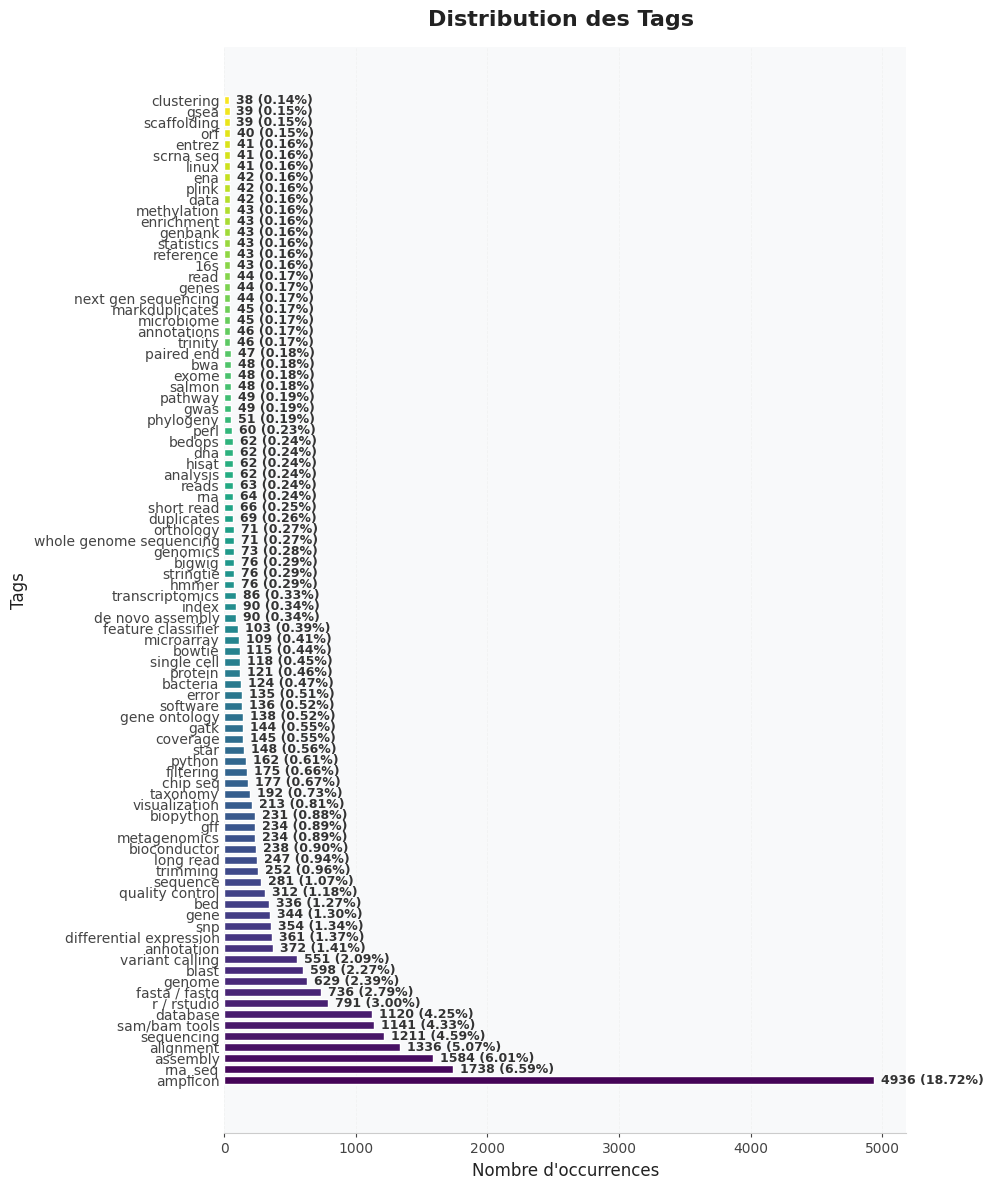

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

all_tags_ranked = df_tags['tag_clean'].value_counts()
tags_51_100 = all_tags_ranked.iloc[0:90]  # R

if not tags_51_100.empty:

    TOTAL_DATASET = 26366  

    fig, ax = plt.subplots(figsize=(10, 12))
    fig.patch.set_facecolor('white')

    # Palette viridis adaptée au nombre de tags
    colors = sns.color_palette("viridis", len(tags_51_100))

    # Barplot horizontal
    bars = ax.barh(tags_51_100.index, tags_51_100.values, color=colors, edgecolor='white', height=0.7)

    # Ajouter valeurs + pourcentages à droite des barres
    for bar, val in zip(bars, tags_51_100.values):
        pct = (val / TOTAL_DATASET) * 100
        ax.text(
            val + TOTAL_DATASET*0.002,  # léger décalage
            bar.get_y() + bar.get_height()/2,
            f"{val} ({pct:.2f}%)",
            va='center',
            fontsize=9,
            fontweight='bold',
            color='#333333'
        )

    # Titre et labels
    ax.set_title("Distribution des Tags ", fontsize=16, fontweight='bold', pad=15)
    ax.set_xlabel("Nombre d'occurrences", fontsize=12)
    ax.set_ylabel("Tags", fontsize=12)

    # Grille subtile
    ax.grid(axis='x', alpha=0.25, linestyle='--')
    ax.set_axisbelow(True)

    # Supprimer les bordures inutiles
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)

    plt.tight_layout()
    plt.show()


synthese

In [28]:
summary_rows = []
for src in sources_available:
    sub = df[df['source'] == src]
    sub_tags = df_tags[df_tags['source'] == src]
    summary_rows.append({
        'Source':            src,
        'N records':         f"{len(sub):,}",
        'N catégories':      sub['category'].nunique(),
        'Catégorie dominante': sub['category'].value_counts().index[0],
        'N tags uniques':    sub_tags['tag'].nunique(),
        'Tag dominant':      sub_tags['tag'].value_counts().index[0] if len(sub_tags) > 0 else 'N/A',
        'Moy tags/record':   f"{sub['n_tags'].mean():.2f}",
        'Moy len instruction': f"{sub['instruction_len'].mean():.0f}",
        'Moy len output':    f"{sub['output_len'].mean():.0f}",
    })

df_summary = pd.DataFrame(summary_rows).set_index('Source')
print('\n=== TABLEAU RÉCAPITULATIF ===')
print(df_summary.to_string())


=== TABLEAU RÉCAPITULATIF ===
                 N records  N catégories        Catégorie dominante  N tags uniques                     Tag dominant Moy tags/record Moy len instruction Moy len output
Source                                                                                                                                                                 
bioconductor           429             3  technical_troubleshooting              28                     Bioconductor            1.41                 138            509
biostackexchange       899             3  technical_troubleshooting              37                    FASTA / FASTQ            1.78                 135            585
biostar              8,624             3  technical_troubleshooting            3444  Amplicon-specific (16S/18S/ITS)            3.79                 142            474
qiime2                 301             3  technical_troubleshooting             100                         taxonomy            2

In [29]:

import json
import numpy as np

OUTPUT_COMBINED_FILE = 'forum_complet.jsonl'

print(f"\n Préparation de l'exportation vers {OUTPUT_COMBINED_FILE}...")

if 'df' in locals() and not df.empty:
    
   
    def clean_record_for_json(row_dict):
        cleaned_dict = {}
        
        
        keys_to_exclude = ['full_text', 'instruction_len', 'output_len', 'n_tags']
        
        for key, value in row_dict.items():
            if key in keys_to_exclude:
                continue
                
            # 
            if value is None:
                continue
            
          
            if isinstance(value, float) and np.isnan(value):
                continue
                
           
            if isinstance(value, np.ndarray):
                cleaned_dict[key] = value.tolist()
            else:
                cleaned_dict[key] = value
                
        return cleaned_dict

    
    records_to_export = df.to_dict(orient='records')
    
    
    print(" Écriture en cours...")
    with open(OUTPUT_COMBINED_FILE, 'w', encoding='utf-8') as f:
        for record in records_to_export:
            clean_json = clean_record_for_json(record)
            f.write(json.dumps(clean_json, ensure_ascii=False) + '\n')

    print(f" Exportation réussie ! {len(records_to_export):,} enregistrements sauvegardés dans '{OUTPUT_COMBINED_FILE}'.")
    
  
    print("\nAperçu d'un enregistrement pour vérifier les champs conservés :")
    
   
    sample_record = df.iloc[0].to_dict()
    
 
    print(json.dumps(clean_record_for_json(sample_record), indent=2, ensure_ascii=False))

else:
    print(" Le DataFrame 'df' n'est pas défini ou est vide.")


 Préparation de l'exportation vers forum_complet.jsonl...
 Écriture en cours...
 Exportation réussie ! 10,253 enregistrements sauvegardés dans 'forum_complet.jsonl'.

Aperçu d'un enregistrement pour vérifier les champs conservés :
{
  "source": "bioconductor",
  "instruction": "Troubleshoot the 'object bbDensity not found' error when running baySeq on a dataset of bacterial community sequences sampled from 6 patients at 4 time points, and advise whether baySeq can handle 4 repeated measures.",
  "input": "Error in .nextMethod(.Object, ...) : object 'bbDensity' not found, baySeq, pairCD <- new(\"countData\", data = list(pairData[,1:4], pairData[,5:8]), replicates = c(1,1,2,2), groups = list(NDE = c(1,1,1,1), DE = c(1,1,2,2)), densityFunction = bbDensity",
  "output": "You are using an old version of baySeq. Update to 2.0.50 from Bioconductor and this should work. This will also allow you to use a densityFunction called mdDensity - this is an extension to the beta-binomial analysis of p